# Recommender Systems - 2026

### You will build and practice the implemention optimization and evaluation of RS model, based on matrix factorization. Finally, you will qualitatively evaluate your models using item similarity.

## Data loading and preparation for training


In [ ]:
import dataclasses

import itertools
import os
import requests
import time
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import mean_squared_error

In [ ]:
url = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"
zip_name = url.split("/")[-1]
data_dir = "ml-100k/"

r = requests.get(url, allow_redirects=True)
with open(zip_name, "wb") as f:
    f.write(r.content)

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall()

In [ ]:
cols_data = ["user_id", "item_id", "rating", "timestamp"]
cols_user = ["user_id", "age", "gender", "occupation", "zip code"]
cols_item = [
    "movie id",
    "movie_title",
    "release_date",
    "video_release_date",
    "IMDb_URL",
    "unknown",
    "Action",
    "Adventure",
    "Animation",
    "Childrens",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film_Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci_Fi",
    "Thriller",
    "War",
    "Western",
]

In [ ]:
df_users = pd.read_csv(
    os.path.join(data_dir, "u.user"),
    delimiter="|",
    header=None,
    names=cols_user,
)
df_users.shape

(943, 5)

In [ ]:
df_items = pd.read_csv(
    os.path.join(data_dir, "u.item"),
    delimiter="|",
    header=None,
    names=cols_item,
    encoding="ISO-8859-1",
)
df_items.shape

(1682, 24)

In [ ]:
df_ratings = pd.read_csv(
    os.path.join(data_dir, "u.data"),
    delimiter="\t",
    header=None,
    names=cols_data,
)
df_ratings.shape

(100000, 4)

---

####Notes regarding the data

When building your model, keep in mind that although you fill empty entries in the rating matrix with zeros, your should handle them as missing ratings (and not as if the user gave a rating zero).

Although item and user side information is available and could be used to further optimize the models, we will focus on the rating data in this task.

In [ ]:
ratings = df_ratings.pivot(
    index="user_id",
    columns="item_id",
    values="rating",
).fillna(0)

ratings.head()

item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
np.random.seed(0)


def train_test_split(
    ratings: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Splits rating matrix to train and test.

    Args:
        ratings: rating matrix.

    Returns:
        Train and test matrices.
    """
    test = ratings.copy()
    test.iloc[:, :] = 0
    train = ratings.copy()
    for user in range(ratings.shape[0]):
        non_zero_items = ratings.iloc[user, :].to_numpy().nonzero()[0]
        test_ratings = np.random.choice(
            non_zero_items, size=10, replace=False)
        train.iloc[user, test_ratings] = 0
        test.iloc[user, test_ratings] = ratings.iloc[user, test_ratings]

    # Test and training are truly disjoint.
    assert(np.all((train * test) == 0))
    return train, test

train, test = train_test_split(ratings)
train.shape, test.shape

((943, 1682), (943, 1682))

---

## Matrix factorization model implementation

In this section, you will implement the matrix factorization model, using batch GD (gradient descent) and ALS (alternating least squares).

Consider the following objective function to be minimized by both algorithms (for simplicity, no need to add bias terms):

<img src='https://drive.google.com/uc?id=1VFtSwgAX8Y9-tQja7bqDntDizTnIg1Ko' width="500">

####GD update step:

<img src='https://drive.google.com/uc?id=1jCfjOf8nMFRM8RTcXZldWwTKPsfpoU-l' width="600">

####ALS update step:
<img src='https://drive.google.com/uc?id=14CmdzwxxaPmAEnTqBPdTWxti0MrwfcoH' width="300">




---

#### Question 1 (50 points)
Implement the following MF algorithms in the designated functions using numpy and pandas only:
1. Batch GD (25 points)
2. ALS (25 points)

Notes:
* Consider edge cases such as division by zero, NaN, Null, Zeros, out of bound, eval time, etc.
* Use vectorized operations.
* Make sure you are not using the test set in your prediction function!!
* You should avoid changing the function signatures.


In [ ]:
@dataclasses.dataclass(frozen=True)
class Metrics:
  # RMSE of training set.
  rmse_train: np.float32
  # RMSE of test set.
  rmse_test: np.float32
  # MRR of test set with cutoff 5.
  mrr5_test: np.float32
  # MRR of test set with cutoff 10.
  mrr10_test: np.float32
  # Mean_NDCG of test set with cutoff 5.
  mean_ndcg5_test: np.float32
  # Mean_NDCG of test set with cutoff 10.
  mean_ndcg10_test: np.float32
  # MAP of test set with cutoff 5.
  map5_test: np.float32
  # MAP of test set with cutoff 10.
  map10_test: np.float32


class ExplicitMF:

    def __init__(
            self,
            train: pd.DataFrame,
            n_factors: int = 10,
            method: str = "pop",
            reg: float = 1e-3,
            n_iterations: int = 20,
            learning_rate: float = 1e-3,
            eps: float = 1e-5,
    ):
        """Trains a matrix factorization model.

        Args:
          train: rating matrix.
          n_factors: number of latent factors in the matrix factorization.
          method: learning algorithm, options: 'pop', 'bias', 'gd', 'als'.
          reg: λ for user and item regularization terms.
          n_iterations: number of iterations for training.
          learning_rate: α.
          eps: stop criteria.
        """
        self.train = train
        self.n_factors = n_factors
        self.method = method
        self.reg = reg
        self.n_iterations = n_iterations
        self.learning_rate = learning_rate
        self.eps = eps
        self.n_users, self.n_items = train.shape
        self.model_params = {}
        self.progress = {}
        self.train_rmse = []
        self.test_rmse = []


    def fit_popularity(self):
        """Computes parameters in a popularity-based algorithm."""
        self.model_params["popularity"] = np.zeros(self.train.shape)
        popularity = self.model_params["popularity"]
        item_avg = np.ma.masked_equal(self.train, value=0).mean(axis=0)
        item_avg[np.isnan(item_avg)] = 0
        for i in range(self.n_items):
            popularity[:, i] = item_avg.data[i]
        self.model_params["popularity"] = popularity
        self.train_rmse.append(self.rmse(self.train))
        self.test_rmse.append(self.rmse(test))


    def fit_bias(self):
        """Computes parameters in a bias-based algorithm."""
        mu = np.ma.masked_equal(self.train, value=0).mean()
        self.model_params["bias"] = np.full(self.train.shape, fill_value=mu)
        bias_params = self.model_params["bias"]
        user_bias = np.ma.masked_equal(self.train - mu, value=-mu).mean(axis=1)
        user_bias[np.isnan(user_bias)] = 0
        item_bias = np.ma.masked_equal(self.train - mu, value=-mu).mean(axis=0)
        item_bias[np.isnan(item_bias)] = 0
        for i in range(self.n_users):
            for j in range(1, self.n_items):
                bias_params[i, j] = mu + user_bias.data[i] + item_bias.data[j]
        self.model_params['bias'] = bias_params
        self.train_rmse.append(self.rmse(self.train))
        self.test_rmse.append(self.rmse(test))


    def update_gd(self):
        """Computes gradient descent step."""

        ### Your Code Here

        # we should avoid where rating == 0 if possible for much better performance
        # we scan train ratings only once for zeros (the first visit to update_gd)
        cache_key = (id(self.train), self.train.shape)
        if not hasattr(self, "non_zero_ratings") or (self.cache_key != cache_key):
            ratings = self.train.to_numpy(dtype=np.float32, copy=False)
            self.users, self.movies = np.nonzero(ratings)    # 2 1d arrays of non zero ratings matching users and movies indices
            self.non_zero_ratings = ratings[self.users, self.movies]    # 1d array
            self.cache_key = cache_key

        users = self.users
        movies = self.movies
        non_zero_ratings = self.non_zero_ratings
        U = self.model_params["U"].astype(np.float32, copy=False)   # defined in training function
        V = self.model_params["V"].astype(np.float32, copy=False)

        # calculating the gradient, taking advantage of ratings sparsity for improved performance
        prediction = np.sum(U[users] * V[movies], axis=1)
        error = non_zero_ratings - prediction
        gradient_U = error.reshape(-1, 1) * V[movies]
        gradient_V = error.reshape(-1, 1) * U[users]
        temp_U = np.zeros_like(U, dtype=np.float32)
        temp_V = np.zeros_like(V, dtype=np.float32)
        np.add.at(temp_U, users, gradient_U)
        np.add.at(temp_V, movies, gradient_V)
        temp_U -= self.reg * U
        temp_V -= self.reg * V
        # final update of U and V (weights)
        self.model_params["U"] = U + self.learning_rate * temp_U
        self.model_params["V"] = V + self.learning_rate * temp_V



    def update_als(self):
        """Computes alternating least squares step."""

        ### Your Code Here

        # handling cache
        cache_key = (id(self.train), self.train.shape)

        # avoiding repeated calculation of ratings_np and non_zero_mask
        if not hasattr(self, "non_zero_mask") or (self.cache_key != cache_key):
          self.ratings_np = self.train.to_numpy(dtype=np.float32, copy=False)
          self.non_zero_mask = (self.ratings_np > 0)
          self.cache_key = cache_key

        R = self.ratings_np
        M = self.non_zero_mask
        U = self.model_params["U"].astype(np.float32, copy=False)
        V = self.model_params["V"].astype(np.float32, copy=False)

        k = self.n_factors
        regI = (self.reg * np.eye(k, dtype=np.float32))

        # fix V, update U
        for u in range(self.n_users):
            idx = np.where(M[u])[0]           # movies/items rated by user u
            if idx.size == 0:
                continue                      # skip
            V_i = V[idx]
            r_u = R[u, idx]

            A = V_i.T @ V_i + regI
            b = V_i.T @ r_u

            # solve A x = b
            U[u] = np.linalg.solve(A, b)

        # fix U, update V
        for i in range(self.n_items):
            idx = np.where(M[:, i])[0]        # users who rated movie/item i
            if idx.size == 0:
                continue                      # skip
            U_u = U[idx]
            r_i = R[idx, i]

            A = U_u.T @ U_u + regI
            b = U_u.T @ r_i

            # solve A x = b
            V[i] = np.linalg.solve(A, b)

        self.model_params["U"] = U
        self.model_params["V"] = V



    def training(self, test: pd.DataFrame):
        """Main method for training all algorithms.

        Args:
            test: test rating matrix.
        """
        if self.method == "pop":
            self.fit_popularity()
            return

        if self.method == "bias":
            self.fit_bias()
            return

        # Initialize latent vectors.
        # self.model_params["U"] = np.random.randn(
        #     self.n_users, self.n_factors) * 0.01
        # self.model_params["V"] = np.random.randn(
        #     self.n_items, self.n_factors) * 0.01

        # added by Noor
        # Initialize latent vectors.
        # using the provided initialization makes the gradient updates too tiny - deminishing gradient effect.
        # which means slow learning and the RMSE barely moves so as a result the stop rule is activated

        # So I will increase the initialization scale, but not too much so we dont get exploding gradients.
        # to do that I will scale with the number of factors k

        # might need to safeguard against k=0
        scale = 1.0 / np.sqrt(self.n_factors)

        self.model_params["U"] = np.random.randn(
            self.n_users, self.n_factors) * scale
        self.model_params["V"] = np.random.randn(
            self.n_items, self.n_factors) * scale

        for i in range(self.n_iterations):
            if i % 10 == 0:
                print(f"\tcurrent iteration: {i}")
            if self.method == "als":
                self.update_als()
            elif self.method == "gd":
                self.update_gd()

            self.train_rmse.append(self.rmse(self.train))
            self.test_rmse.append(self.rmse(test))
            # Don't break in the first iteration.
            if not i:
                continue

            if self.eps > abs(self.train_rmse[i] - self.train_rmse[i-1]):
                break


    def recommend_unseen(self, user: int, n_items: int) -> list:
        """Recommends unseen items per user, oredered by predicted ratings desc.

        Args:
          user: user id.
          n_items: number of items to suggest.

        Returns:
          Top suggestions.
        """
        if self.method == "pop":
            predicted_ratings = self.model_params["popularity"][user]
        elif self.method == "bias":
            predicted_ratings = self.model_params["bias"][user]
        else:
            user_vec = self.model_params["U"][user, :]
            predicted_ratings = user_vec @ self.model_params["V"].T

        pred_sorted = np.argsort(predicted_ratings)[::-1]
        unseen_movie = np.where(self.train.iloc[user] == 0)
        final = pred_sorted[np.in1d(pred_sorted, unseen_movie)]
        return final[:n_items]


    def predict(self, user: int, item: int) -> float:
        """Predicts the rating of a specific item for a specific user.

        Args:
          user: user id.
          item: item id.

        Returns:
          Predicted rating.
        """
        if self.method == "pop":
            return self.model_params["popularity"][user, item]

        if self.method == "bias":
            return  self.model_params["bias"][user, item]

        user_vec = self.model_params["U"][user, :]
        item_vec = self.model_params["V"][item, :]
        return np.dot(user_vec, item_vec)


    def predict_all(self):
        """Predicts ratings for every user and item.

        Args: None

        Returns:
            All predicted ratings
        """
        # predictions = np.zeros(shape=(self.n_users, self.n_items))
        # for u in range(self.n_users):
        #     for i in range(self.n_items):
        #         predictions[u, i] = self.predict(u, i)
        # return predictions

        # added by Noor
        # the original predict_all is too expensive (two for loops)
        # we wil replace with more efficient vectorized implementation
        # vectorizing this function made a huge performance difference
        # ALS grid search is done in less than a minute compared to ~30 mins before vectorization

        if self.method == "pop":
            return self.model_params["popularity"]
        if self.method == "bias":
            return self.model_params["bias"]
        return self.model_params["U"] @ self.model_params["V"].T


    def rmse(self, actual: pd.DataFrame) -> float:
        """Computes the total RMSE of a model, compared to the actual rating.

        Args:
          actual: actual rating matrix.

        Returns:
          Total RMSE.
        """
        # preds = self.predict_all()
        # preds = preds[actual > 0].flatten()
        # actual = actual.to_numpy()
        # actual_non_zeros = actual[actual > 0].flatten()
        # rmse = np.sqrt(np.mean((actual_non_zeros - preds)**2))
        # return rmse


        # we will vectorize rmse for better performance
        preds = self.predict_all().astype(np.float32, copy=False)
        actual_np = actual.to_numpy(dtype=np.float32, copy=False)
        mask_rated = (actual_np > 0)
        if not np.any(mask_rated):
            return 0.0
        diff = actual_np[mask_rated] - preds[mask_rated]
        return float(np.sqrt(np.mean(diff * diff)))


    def mrr(self, test: pd.DataFrame, k: int = 5) -> float:
        """Computes the Mean Reciprocal Rank for all users.

        Note: relevancy is considered rating 3 or above.

        Args:
          test: rating matrix.
          k: cutoff value.

        Returns:
          MRR.
        """
        mrr = 0
        for user in range(self.n_users):
            list_pred = self.recommend_unseen(user, k)
            user_test = test.iloc[user]
            for j in range(k):
                if user_test.iloc[list_pred[j]] >= 3:
                    mrr += 1 / (j + 1)
                    break
        return mrr / self.n_users


    def dcg(self, user: int, test: pd.DataFrame, k: int = 5) -> float:
        """Computes the Discounted Cumulative Gain for a given user.

        Args:
            user: user id.
            test: rating matrix.
            k: cutoff value.

        Returns:
            DCG.
        """
        rank_pred = self.recommend_unseen(user, k)
        user_test = test.iloc[user]
        actual = user_test[user_test >= 0]

        dcg = 0
        for j in range(k):
            if rank_pred[j] in actual:
                rating = user_test.iloc[rank_pred[j]]
                m = rating / np.log2(j + 2)
                dcg += m
        return dcg


    def idcg(self, user: int, test: pd.DataFrame, k: int = 5) -> float:
        """Computes the Idealized Discounted Cumulative Gain for a given user.

        Args:
            user: user id.
            test: rating matrix.
            k: cutoff value.

        Returns:
            iDCG.
        """
        user_test = test.iloc[user]
        actual = user_test[user_test >= 0]
        true_sort = actual.sort_values(ascending=False)[:k]
        idcg = 0
        for i in range(len(true_sort)):
            m = true_sort.iloc[i] / np.log2(i + 2)
            idcg += m
        return idcg


    def mean_ndcg(self, test: pd.DataFrame, k: int = 5) -> float:
        """Computes Mean Normalized Discounted Cumulative Gain for all users.

        Args:
          test: rating matrix.
          k: cutoff value.

        Returns:
          Mean nDCG.
        """
        ndcg = 0
        for user in range(self.n_users):
            dcg = self.dcg(user, test, k)
            idcg = self.idcg(user, test, k)
            if idcg > 0:
                m = dcg / idcg
            else:
                m = 0
            ndcg += m
        return ndcg / self.n_users


    def map(self, test: pd.DataFrame, k: int = 5) -> float:
        """Computes the mean average precision for all users.

        Note: relevancy is considered rating 3 or above.

        Args:
          test: rating matrix.
          k: cutoff value.

        Returns:
          Overall MAP.
        """
        ap_list = []
        for user in range(self.n_users):
            list_pred = self.recommend_unseen(user, k)
            user_test = test.iloc[user]
            ap = []
            hits = 0
            for j in range(k):
                if user_test.iloc[list_pred[j]] >= 3:
                    hits += 1
                    ap.append(hits / (j + 1))
            if ap:
                ap_list.append(np.mean(ap))
            else:
                ap_list.append(0)
        map = np.mean(ap_list)
        return map


    def get_all_metrics(self, test: pd.DataFrame) -> Metrics:
      """Gets all metrics of the trained model.

      Args:
        test: rating matrix.

      Returns:
        Metrics object.
      """
      return Metrics(
          rmse_train=self.rmse(self.train),
          rmse_test=self.rmse(test),
          mrr5_test=self.mrr(test, 5),
          mrr10_test=self.mrr(test, 10),
          mean_ndcg5_test=self.mean_ndcg(test, 5),
          mean_ndcg10_test=self.mean_ndcg(test, 10),
          map5_test=self.map(test, 5),
          map10_test=self.map(test, 10),
          )


In [ ]:
def plot_learning_curve(model: ExplicitMF):
    """Plots learning curve.

    Args:
        model: trained RS model.
    """
    plt.plot(model.train_rmse, label="Training", linewidth=5)
    plt.plot(model.test_rmse, label="Test", linewidth=5)
    plt.xlabel("iterations");
    plt.ylabel("RMSE");
    plt.legend(loc="best");

###Train all models with the default parameters

In [ ]:
results = []

Popularity model

In [ ]:
method = "pop"
pop = ExplicitMF(train, method=method)
start_time = time.time()
pop.training(test)
training_time = time.time() - start_time
print(f"--- {training_time} seconds ---")
metrics = pop.get_all_metrics(test)
results.append(
    [method] + list(dataclasses.astuple(metrics)) + [training_time]
)

--- 0.05755114555358887 seconds ---


/tmp/ipython-input-3021957060.py:254: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  final = pred_sorted[np.in1d(pred_sorted, unseen_movie)]


Bias model

In [ ]:
method = "bias"
bias = ExplicitMF(train, method=method)
start_time = time.time()
bias.training(test)
training_time = time.time() - start_time
print(f"--- {training_time} seconds ---")
metrics = bias.get_all_metrics(test)
results.append(
    [method] + list(dataclasses.astuple(metrics)) + [training_time]
)

--- 1.562180519104004 seconds ---


/tmp/ipython-input-3021957060.py:254: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  final = pred_sorted[np.in1d(pred_sorted, unseen_movie)]


Gradient descent model

	current iteration: 0
	current iteration: 10
--- 2.359145402908325 seconds ---


/tmp/ipython-input-3021957060.py:254: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  final = pred_sorted[np.in1d(pred_sorted, unseen_movie)]


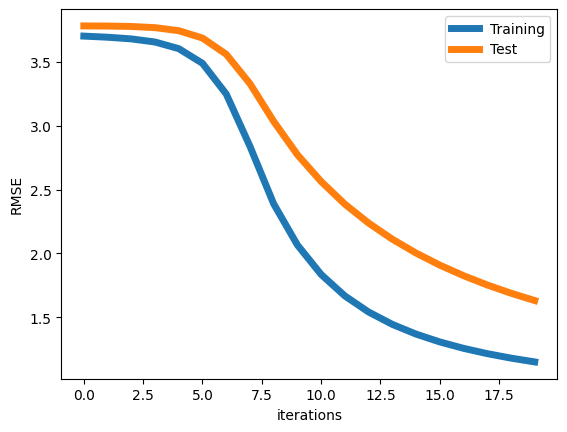

In [ ]:
method = "gd"
gd = ExplicitMF(train, method=method)
start_time = time.time()
gd.training(test)
training_time = time.time() - start_time
print(f"--- {training_time} seconds ---")
metrics = gd.get_all_metrics(test)
results.append(
    [method] + list(dataclasses.astuple(metrics)) + [training_time]
)
plot_learning_curve(gd)

ALS model

	current iteration: 0
	current iteration: 10
--- 3.2488112449645996 seconds ---


/tmp/ipython-input-3021957060.py:254: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  final = pred_sorted[np.in1d(pred_sorted, unseen_movie)]


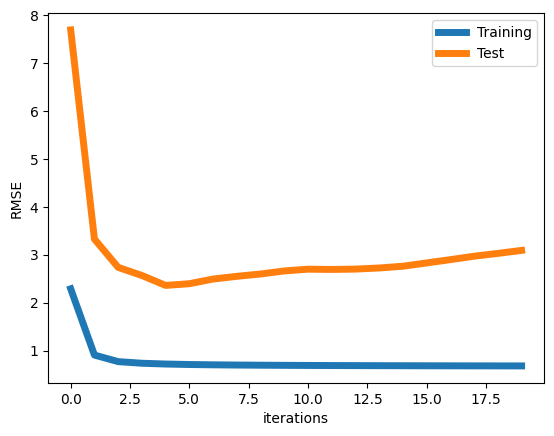

In [ ]:
method = "als"
als = ExplicitMF(train, method=method)
start_time = time.time()
als.training(test)
training_time = time.time() - start_time
print(f"--- {training_time} seconds ---")
metrics = als.get_all_metrics(test)
results.append(
    [method] + list(dataclasses.astuple(metrics)) + [training_time]
)
plot_learning_curve(als)

Compare of the different models using various metrics

In [ ]:
columns = [
    "RMSE training",
    "RMSE test",
    "MRR k=5 test",
    "MRR k=10 test",
    "Mean NDCG k=5 test",
    "Mean NDCG k=10 test",
    "MAP k=5 test",
    "MAP k=10 test",
    "Training time",
]


def results_to_dataframe(results: list) -> pd.DataFrame:
    """Prepares results for table.

    Args:
        results: results list.

    Returns:
        Results table.
    """

    results_pd = pd.DataFrame(results).set_index(0)
    results_pd = results_pd.set_index(results_pd.index.rename("Model / Metric"))
    results_pd.columns = columns
    return results_pd


lower_better = ["RMSE training", "RMSE test", "Training time"]
higher_better = list(set(columns) - set(lower_better))
results_pd = results_to_dataframe(results)
results_pd.style.background_gradient(
    "RdYlGn_r", axis=0, subset=lower_better,
).background_gradient("RdYlGn", axis=0, subset=higher_better)

,RMSE training,RMSE test,MRR k=5 test,MRR k=10 test,Mean NDCG k=5 test,Mean NDCG k=10 test,MAP k=5 test,MAP k=10 test,Training time
Model / Metric,,,,,,,,,
pop,3.135076,3.158335,0.271615,0.292632,0.119304,0.112602,0.257974,0.263624,0.057551
bias,2.953727,3.168389,0.269512,0.294750,0.122084,0.118749,0.258749,0.267975,1.562181
gd,1.150416,1.631127,0.112071,0.129322,0.050247,0.053469,0.110410,0.120409,2.359145
als,0.679687,3.092320,0.001060,0.001540,0.000494,0.000586,0.001060,0.001540,3.248811


### Hyperparameter tuning - ALS
Now that we have trained our models with the default hyperparameters, it's time to find their optimal values using grid search.

Factors: 5
iterations: 25
regularization: 0.001
	current iteration: 0
	current iteration: 10
	current iteration: 20


/tmp/ipython-input-3021957060.py:254: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  final = pred_sorted[np.in1d(pred_sorted, unseen_movie)]


New optimal hyperparameters
n_factors                                                  5
reg                                                    0.001
n_iter                                                    25
train_rmse                                           0.84215
test_rmse                                           1.419688
model         <__main__.ExplicitMF object at 0x7e3ff161e7b0>
dtype: object
--- 4.94319748878479 seconds ---
Factors: 5
iterations: 25
regularization: 0.01
	current iteration: 0
	current iteration: 10
	current iteration: 20
New optimal hyperparameters
n_factors                                                  5
reg                                                     0.01
n_iter                                                    25
train_rmse                                          0.812554
test_rmse                                           1.282928
model         <__main__.ExplicitMF object at 0x7e3ff1b4b1a0>
dtype: object
--- 3.8211147785186768 seconds ---
F

,RMSE training,RMSE test,MRR k=5 test,MRR k=10 test,Mean NDCG k=5 test,Mean NDCG k=10 test,MAP k=5 test,MAP k=10 test,Training time
Model / Metric,,,,,,,,,
pop,3.135076,3.158335,0.271615,0.292632,0.119304,0.112602,0.257974,0.263624,0.057551
bias,2.953727,3.168389,0.269512,0.294750,0.122084,0.118749,0.258749,0.267975,1.562181
gd,1.150416,1.631127,0.112071,0.129322,0.050247,0.053469,0.110410,0.120409,2.359145
als,0.679687,3.092320,0.001060,0.001540,0.000494,0.000586,0.001060,0.001540,3.248811
als_fact_5_reg_0.001_iter_25,0.779011,2.120534,0.000566,0.000566,0.000254,0.000224,0.000566,0.000566,4.943197
als_fact_5_reg_0.01_iter_25,0.775082,1.477388,0.000477,0.000831,0.000369,0.000517,0.000477,0.000831,3.821115
als_fact_5_reg_0.1_iter_25,0.774534,1.161835,0.000689,0.003688,0.000362,0.002242,0.000689,0.003688,3.802243


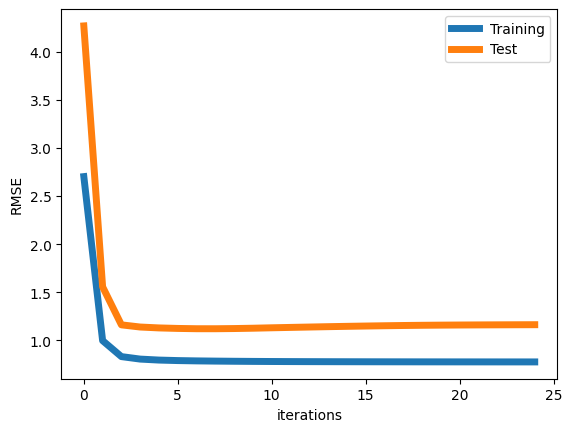

In [ ]:
latent_factors = [5, 10, 20]
regularizations = [0.001, 0.01, 0.1]
iter_array = [25]

best_params = {}
best_params["n_factors"] = latent_factors[0]
best_params["reg"] = regularizations[0]
best_params["n_iter"] = iter_array[0]
best_params["train_rmse"] = np.inf
best_params["test_rmse"] = np.inf
best_params["model"] = None


for fact, n_iter, reg in itertools.product(
    latent_factors, iter_array, regularizations):
    print(f"Factors: {fact}")
    print(f"iterations: {n_iter}")
    print(f"regularization: {reg}")

    method = "als"
    model_name = "".join([
        method,
        "_fact_", str(fact),
        "_reg_", str(reg),
        "_iter_", str(n_iter)
    ])
    als_grid = ExplicitMF(
        train=train,
        method=method,
        n_factors=fact,
        n_iterations=n_iter,
        reg=reg,
    )
    start_time = time.time()
    als_grid.training(test)
    training_time = time.time() - start_time
    min_idx = np.argmin(als_grid.test_rmse)
    if als_grid.test_rmse[min_idx] >= best_params["test_rmse"]:
        continue

    metrics = als_grid.get_all_metrics(test)
    results.append(
        [model_name] + list(dataclasses.astuple(metrics)) + [training_time])
    best_params["n_factors"] = fact
    best_params["reg"] = reg
    best_params["n_iter"] = n_iter
    best_params["train_rmse"] = als_grid.train_rmse[min_idx]
    best_params["test_rmse"] = als_grid.test_rmse[min_idx]
    best_params["model"] = als_grid
    print("New optimal hyperparameters")
    print(pd.Series(best_params))
    print(f"--- {training_time} seconds ---")

best_als_model = best_params["model"]
plot_learning_curve(best_als_model)

results_pd = results_to_dataframe(results)
results_pd.style.background_gradient(
    "RdYlGn_r", axis=0, subset=lower_better,
).background_gradient("RdYlGn", axis=0, subset=higher_better)

---

#### Question 2 (10 points)

If there are any hyperparameters that could be further tuned (for example, if the best value for a hyperparameter is at the maximun of the grid scale), expand the grid search and continue the exploration. Make sure all your experiments are documented in the results table.

Which are the best hyperparameters for the ALS model?

Discuss your observations (overfitting, etc.)



Factors: 3
iterations: 10
regularization: 0.01
	current iteration: 0


/tmp/ipython-input-3021957060.py:254: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  final = pred_sorted[np.in1d(pred_sorted, unseen_movie)]


New optimal hyperparameters
n_factors                                                  3
reg                                                     0.01
n_iter                                                    10
train_rmse                                           0.82869
test_rmse                                           1.042859
model         <__main__.ExplicitMF object at 0x7e3ff0ccdf40>
dtype: object
--- 1.5259740352630615 seconds ---
Factors: 3
iterations: 10
regularization: 0.1
	current iteration: 0
New optimal hyperparameters
n_factors                                                  3
reg                                                      0.1
n_iter                                                    10
train_rmse                                          0.830829
test_rmse                                           1.039715
model         <__main__.ExplicitMF object at 0x7e3ff0d6fbf0>
dtype: object
--- 1.4648942947387695 seconds ---
Factors: 3
iterations: 10
regularization: 0.5


,RMSE training,RMSE test,MRR k=5 test,MRR k=10 test,Mean NDCG k=5 test,Mean NDCG k=10 test,MAP k=5 test,MAP k=10 test,Training time
Model / Metric,,,,,,,,,
pop,3.135076,3.158335,0.271615,0.292632,0.119304,0.112602,0.257974,0.263624,0.057551
bias,2.953727,3.168389,0.269512,0.294750,0.122084,0.118749,0.258749,0.267975,1.562181
gd,1.150416,1.631127,0.112071,0.129322,0.050247,0.053469,0.110410,0.120409,2.359145
als,0.679687,3.092320,0.001060,0.001540,0.000494,0.000586,0.001060,0.001540,3.248811
als_fact_5_reg_0.001_iter_25,0.779011,2.120534,0.000566,0.000566,0.000254,0.000224,0.000566,0.000566,4.943197
als_fact_5_reg_0.01_iter_25,0.775082,1.477388,0.000477,0.000831,0.000369,0.000517,0.000477,0.000831,3.821115
als_fact_5_reg_0.1_iter_25,0.774534,1.161835,0.000689,0.003688,0.000362,0.002242,0.000689,0.003688,3.802243
als_fact_3_reg_0.01_iter_10,0.828311,1.043756,0.000795,0.001053,0.000471,0.000478,0.000795,0.001053,1.525974
als_fact_3_reg_0.1_iter_10,0.830829,1.039715,0.002916,0.006708,0.001501,0.003940,0.002916,0.006879,1.464894


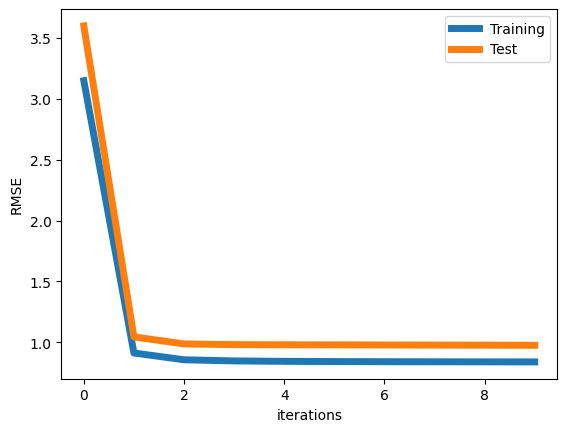

In [ ]:
latent_factors = [3, 5, 10]
regularizations = [0.01, 0.1, 0.5, 0.7, 1, 2, 4]
iter_array = [10, 20]

best_params = {}
best_params["n_factors"] = latent_factors[0]
best_params["reg"] = regularizations[0]
best_params["n_iter"] = iter_array[0]
best_params["train_rmse"] = np.inf
best_params["test_rmse"] = np.inf
best_params["model"] = None


for fact, n_iter, reg in itertools.product(
    latent_factors, iter_array, regularizations):
    print(f"Factors: {fact}")
    print(f"iterations: {n_iter}")
    print(f"regularization: {reg}")

    method = "als"
    model_name = "".join([
        method,
        "_fact_", str(fact),
        "_reg_", str(reg),
        "_iter_", str(n_iter)
    ])
    als_grid = ExplicitMF(
        train=train,
        method=method,
        n_factors=fact,
        n_iterations=n_iter,
        reg=reg,
    )
    start_time = time.time()
    als_grid.training(test)
    training_time = time.time() - start_time
    min_idx = np.argmin(als_grid.test_rmse)
    if als_grid.test_rmse[min_idx] >= best_params["test_rmse"]:
        continue

    metrics = als_grid.get_all_metrics(test)
    results.append(
        [model_name] + list(dataclasses.astuple(metrics)) + [training_time])
    best_params["n_factors"] = fact
    best_params["reg"] = reg
    best_params["n_iter"] = n_iter
    best_params["train_rmse"] = als_grid.train_rmse[min_idx]
    best_params["test_rmse"] = als_grid.test_rmse[min_idx]
    best_params["model"] = als_grid
    print("New optimal hyperparameters")
    print(pd.Series(best_params))
    print(f"--- {training_time} seconds ---")

best_als_model = best_params["model"]
plot_learning_curve(best_als_model)

results_pd = results_to_dataframe(results)
results_pd.style.background_gradient(
    "RdYlGn_r", axis=0, subset=lower_better,
).background_gradient("RdYlGn", axis=0, subset=higher_better)

``` Your response here ```

For the initially provided grid search the ALS clearly overfits, so increasing the regularization parameter λ in the objective function can probably help. This is also supported by the results of the initial provided grid search where we get the best performing ALS on the test set when using the highest λ. So to further improve the performance we should try higher λ.

After expanding the grid search to include higher values of the regularization parameter, the ALS model achieved its best test RMSE with n_factors = 3, reg = 2, and n_iter = 10. This configuration provides the strongest generalization performance in terms of rating prediction accuracy.

The experimental results indicate that ALS is highly sensitive to both model complexity and regularization strength. Models with a larger number of latent factors and low regularization obtain very low training error but perform poorly on the test set, which is a clear sign of overfitting. In such cases, the model learns patterns specific to the training data rather than general trends.

In contrast, the selected configuration uses a small latent dimension and strong regularization, which limits model complexity and reduces variance. This leads to higher training error but improved test performance, indicating better generalization. However, the strong regularization also reduces the model’s ability to distinguish between items, resulting in weaker ranking-based metrics. Overall, these results demonstrate the tradeoff between overfitting and underfitting in ALS and show that the optimal hyperparameters depend on the evaluation objective.



---

### Hyperparameter tuning - GD


#### Question 3 (15 points)
Repeat the process of grid search for the gradient descent model.
Don't forget to include also learning rate optimization. Make sure all your experiments are documented in the results table.


Factors: 3, Iterations: 100, Reg: 0.001, LR: 0.0001
	current iteration: 0
	current iteration: 10
	current iteration: 20
	current iteration: 30
	current iteration: 40
	current iteration: 50
	current iteration: 60
	current iteration: 70
	current iteration: 80
	current iteration: 90


/tmp/ipython-input-3021957060.py:254: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  final = pred_sorted[np.in1d(pred_sorted, unseen_movie)]


New optimal hyperparameters
n_factors                                                     3
reg                                                       0.001
n_iter                                                      100
learning_rate                                            0.0001
train_rmse                                             2.359269
test_rmse                                              3.027308
model            <__main__.ExplicitMF object at 0x7e3ff0e05670>
dtype: object
--- 8.990368127822876 seconds ---
Factors: 3, Iterations: 100, Reg: 0.001, LR: 0.001
	current iteration: 0
	current iteration: 10
	current iteration: 20
	current iteration: 30
	current iteration: 40
	current iteration: 50
	current iteration: 60
	current iteration: 70
	current iteration: 80
	current iteration: 90
New optimal hyperparameters
n_factors                                                     3
reg                                                       0.001
n_iter                                  

,RMSE training,RMSE test,MRR k=5 test,MRR k=10 test,Mean NDCG k=5 test,Mean NDCG k=10 test,MAP k=5 test,MAP k=10 test,Training time
Model / Metric,,,,,,,,,
pop,3.135076,3.158335,0.271615,0.292632,0.119304,0.112602,0.257974,0.263624,0.057551
bias,2.953727,3.168389,0.269512,0.294750,0.122084,0.118749,0.258749,0.267975,1.562181
gd,1.150416,1.631127,0.112071,0.129322,0.050247,0.053469,0.110410,0.120409,2.359145
als,0.679687,3.092320,0.001060,0.001540,0.000494,0.000586,0.001060,0.001540,3.248811
als_fact_5_reg_0.001_iter_25,0.779011,2.120534,0.000566,0.000566,0.000254,0.000224,0.000566,0.000566,4.943197
als_fact_5_reg_0.01_iter_25,0.775082,1.477388,0.000477,0.000831,0.000369,0.000517,0.000477,0.000831,3.821115
als_fact_5_reg_0.1_iter_25,0.774534,1.161835,0.000689,0.003688,0.000362,0.002242,0.000689,0.003688,3.802243
als_fact_3_reg_0.01_iter_10,0.828311,1.043756,0.000795,0.001053,0.000471,0.000478,0.000795,0.001053,1.525974
als_fact_3_reg_0.1_iter_10,0.830829,1.039715,0.002916,0.006708,0.001501,0.003940,0.002916,0.006879,1.464894


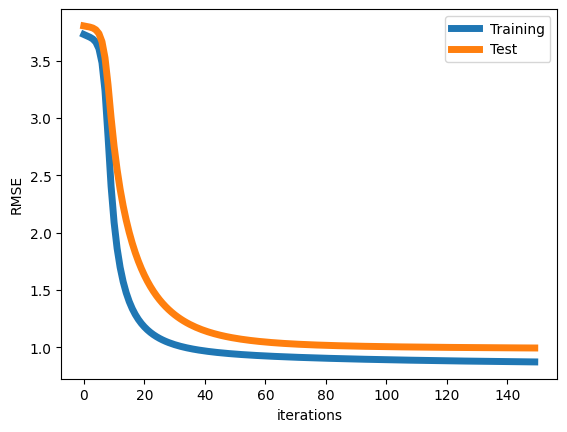

In [ ]:
# Your code here

# default params:
# n_factors: int = 10,
# method: str = "pop",
# reg: float = 1e-3,
# n_iterations: int = 20,
# learning_rate: float = 1e-3,
# eps: float = 1e-5



latent_factors = [3, 4, 6]
regularizations = [0.001, 0.08, 0.1, 1, 2.5, 3]
iter_array = [100, 150]
learning_rates = [0.0001, 0.001]

best_params = {
    "n_factors": latent_factors[0],
    "reg": regularizations[0],
    "n_iter": iter_array[0],
    "learning_rate": learning_rates[0],
    "train_rmse": np.inf,
    "test_rmse": np.inf,
    "model": None,
}

for fact, n_iter, reg, lr in itertools.product(
    latent_factors, iter_array, regularizations, learning_rates
):
    print(f"Factors: {fact}, Iterations: {n_iter}, Reg: {reg}, LR: {lr}")

    method = "gd"
    model_name = "".join([
        method,
        "_fact_", str(fact),
        "_reg_", str(reg),
        "_iter_", str(n_iter),
        "_lr_", str(lr),
    ])

    gd_grid = ExplicitMF(
        train=train,
        method=method,
        n_factors=fact,
        n_iterations=n_iter,
        reg=reg,
        learning_rate=lr,
    )

    start_time = time.time()
    gd_grid.training(test)
    training_time = time.time() - start_time

    min_idx = np.argmin(gd_grid.test_rmse)
    if gd_grid.test_rmse[min_idx] >= best_params["test_rmse"]:
        continue

    metrics = gd_grid.get_all_metrics(test)
    results.append(
        [model_name] + list(dataclasses.astuple(metrics)) + [training_time]
    )

    best_params.update({
        "n_factors": fact,
        "reg": reg,
        "n_iter": n_iter,
        "learning_rate": lr,
        "train_rmse": gd_grid.train_rmse[min_idx],
        "test_rmse": gd_grid.test_rmse[min_idx],
        "model": gd_grid,
    })

    print("New optimal hyperparameters")
    print(pd.Series(best_params))
    print(f"--- {training_time} seconds ---")

best_gd_model = best_params["model"]
plot_learning_curve(best_gd_model)

results_pd = results_to_dataframe(results)
results_pd.style.background_gradient(
    "RdYlGn_r", axis=0, subset=lower_better,
).background_gradient(
    "RdYlGn", axis=0, subset=higher_better
)

---

#### Question 4 (5 points)

Which are the best hyperparameters for the GD model?

Discuss your observations (overfitting, etc.)


``` Your response here ```

Based on the grid search results, the best gradient descent (GD) model is obtained with n_factors = 3, reg = 0.001, n_iter = 150, and learning_rate = 0.001. This configuration achieves the lowest test RMSE among all tested GD models, indicating the best generalization performance.

The experimental results highlight a clear trade-off between training error, test error, and computational cost. While increasing the number of iterations consistently reduces the training RMSE, improvements in test RMSE diminish after a certain point, indicating convergence. The selected configuration achieves a low training RMSE while maintaining a small gap to the test RMSE, suggesting effective control of overfitting. In contrast, models with fewer iterations tend to underfit, while models with weaker regularization exhibit lower training error but higher test error, a clear sign of overfitting.

Learning rate selection plays a critical role in both model stability and performance. Larger learning rates (e.g., 0.005 and 0.01) led to numerical instability and exploding gradients effect, resulting in overflow warnings and invalid values (NaN or Inf), and were therefore unsuitable despite their faster apparent convergence.

This sensetivity to higher learning rates is probably due to the increased initial weights of U and V that we had to apply due to the provided initial weights causing a deminishing gradients effect, which limits increasing learning rates more than a specific theshold. So clearly there's a trade-off between increased learning rate and increased initial weights. A learning rate of 0.001 provides a stable optimization process, balancing convergence speed and numerical robustness.

From a computational perspective, increasing the number of iterations leads to longer training times; however, the selected configuration represents a reasonable compromise between training time and predictive performance. Although models with fewer iterations train faster, they fail to achieve comparable accuracy, while models with higher complexity or unstable learning rates offer no additional performance gains.

Overall, the chosen hyperparameters strike an effective balance between model complexity, generalization accuracy, numerical stability, and computational efficiency, resulting in a robust GD model with reliable performance across multiple evaluation metrics.

---

####Question 5 (5 points)

Compare all models trained (popularity, bias, ALS, GD); Are different models better when considering different metrics? Discuss the reasoning. Discuss your insights regarding the models performance (accuracy, time to train etc.). Describe possible tasks and their corresponding preferable model.

``` Your response here ```

The experimental results indicate that different recommendation models are better suited to different evaluation criteria and application scenarios. Simple baseline models, such as popularity and bias, achieve relatively high ranking metrics (MRR, NDCG, and MAP) by recommending frequently interacted items. However, they perform poorly in terms of RMSE, reflecting limited ability to model personalized user preferences. Due to their very short training time, these models are useful as baselines or in cold-start scenarios where personalization is limited.

After hyperparameter optimization, the ALS model shows a significant improvement over its baseline configuration. The optimized ALS configurations achieve much lower test RMSE and substantially better ranking metrics, indicating improved generalization and recommendation quality. However, even with well-chosen hyperparameters, ALS exhibits a noticeable gap between training and test RMSE in some settings, suggesting a tendency toward overfitting. Additionally, ALS requires relatively long training time, which makes it more suitable for offline recommendation systems where model updates are infrequent and computational cost is less critical.

Similarly, the optimal GD-based matrix factorization model demonstrates clear improvements compared to the initial MF GD model. The GD model achieves one of the lowest test RMSE values among all evaluated models, while maintaining a smaller gap between training and test RMSE, indicating better control of overfitting. In addition, GD provides competitive performance across ranking metrics such as MRR, NDCG, and MAP. The primary limitation of GD is its higher training time, especially when using a large number of iterations, reflecting the trade-off between convergence quality and computational efficiency.

Overall, no single model dominates across all metrics. Popularity and bias models are preferable for fast, low-cost recommendations or cold-start settings. ALS models are effective for offline scenarios where latent factor modeling and high recommendation quality are required, and training time is less of a concern. GD models offer a strong balance between generalization performance, ranking quality, and stability, making them suitable for applications that require accurate and robust recommendations, albeit at a higher computational cost.

---

####Question 6 (5 points)

Suggest possible enhancements that could potentially improve your models (no need to implement).

``` Your response here ```


*   In the ALS update step, inside the for loops: for every user we scan all items (np.where(M[u]) and for every item we scan all users (np.where(M[:, i]). Instead of this we can utilize grouped non-zero indices which would be much faster training time wise, since we would only go over non-zero items instead of n_users * n_items while scanning.

* For MF models, use different regulariztion parameters λ_u for U and λ_v for V. This can help reduces test RMSE.

* Incorporate biases inside MF models training, this can help reduce test RMSE.

* We can decrease Learning every specific number of iterations to avoid overshooting the minimum, balancing exploration and exploitation.



---

## Model explainability
In this section, you will try to qualitatively asses the results of your models



#### Question 7 (5 points)

Select an item similarity method which you find best suitable for this dataset and implement it using numpy and pandas only.

In [ ]:
def similarity(model: ExplicitMF) -> np.ndarray:
    """Computes item-to-item similarity.

    Args:
        model: trained RS model.

    Returns:
        Similarity matrix.
    """
    # Your code here

    # Adjusted cosine similarity is well suited for explicit rating data,
    # as it removes user rating bias.
    # However, in our comparison we aim to qualitatively compare recommendations
    # produced by different models. Therefore, item similarity is computed using
    # cosine similarity over each model’s predicted rating matrix or item embeddings.
    # For MF models we will calculate similarity over item embeddings.
    # This ensures that the similarity reflects model-specific learned structure
    # rather than the original data alone.

    # cosine_sim(i, j) = (sum_u P[u, i] * P[u, j]) / (sqrt(sum_u P[u, i]^2) * sqrt(sum_u P[u, j]^2))

    # implementing using matrix form

    method = model.method
    # calc similarity for MF models utilizing item embeddings
    if method in ("gd", "als"):
        V = np.asarray(model.model_params["V"], dtype=np.float32)
        # normalize each item vector
        norms = np.linalg.norm(V, axis=1, keepdims=True)
        V_normalized = np.divide(V, norms, out=np.zeros_like(V), where=(norms != 0))
        # cosine similarity
        similarity = V_normalized @ V_normalized.T
        np.fill_diagonal(similarity, 1.0)
        # print(model.method, similarity[:6, :6])              # testing
        return similarity.astype(np.float32, copy=False)

    # for non MF models
    # predict ratings
    P = np.asarray(model.predict_all(), dtype=np.float32)
    # P matrix is full, so for every pair of items all users "rated" both
    numerator = P.T @ P
    # calculate the L2 norm of of every item
    item_norm = np.sqrt((P * P).sum(axis=0, dtype=np.float32), dtype=np.float32)
    # calculate the denominator
    denominator = item_norm[:, None] * item_norm[None, :]
    # safe division with warning removal
    with np.errstate(divide='ignore', invalid='ignore'):
        similarity = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=(denominator!=0))
    # for identical item return similarity 1
    np.fill_diagonal(similarity, 1.0)
    # print(model.method, similarity[:6, :6])              # testing
    return similarity.astype(np.float32, copy=False)


pop_sim = similarity(pop)
bias_sim = similarity(bias)
als_sim = similarity(best_als_model)
gd_sim = similarity(best_gd_model)

In [ ]:
def display_top_k_movies(similarity: np.ndarray, movie_idx: int, k: int = 5):
    """Prints most similar movies.

    Args:
        similarity: similarity matrix.
        movie_idx: movie index.
        k: number of similar movies to print.
    """
    movie_indices = np.argsort(similarity[movie_idx, :])[::-1]
    movie_titles = []
    # Start i at 1 to not grab the input movie.
    i = 1
    while i <= k:
        movie_titles.append(df_items['movie_title'][movie_indices[i]])
        i += 1
    print("Recommended movies: ", movie_titles)


def compare_recs(pop_similarity: np.ndarray, bias_similarity: np.ndarray,
                 als_similarity: np.ndarray, gd_similarity: np.ndarray,
                 movie_idx: int, k: int = 5):
    """Prints most similar movies in every model.

    Args:
        pop_similarity: similarity matrix for popularity model.
        bias_similarity: similarity matrix for bias model.
        als_similarity: similarity matrix for als model.
        gd_similarity: similarity matrix for gd model.
        movie_idx: movie index.
        k: number of similar movies to print.
    """
    print("Input movie: ", df_items['movie_title'][movie_idx])

    print("Popularity model recommendations:")
    display_top_k_movies(pop_similarity, movie_idx, k)

    print("Bias model recommendations:")
    display_top_k_movies(bias_similarity, movie_idx, k)

    print("GD model recommendations:")
    display_top_k_movies(gd_similarity, movie_idx, k)

    print("ALS model recommendations:")
    display_top_k_movies(als_similarity, movie_idx, k)


---

####Question 8 (5 points)

Compare between the recommendations of the various models.

Show the recommendations for three movies and discuss the quality of the results obtained by the different models.

``` Your response here ```
# Justifying Similarity Method of Choice:
As we learned in class Adjusted Cosine Similarity is well suited for explicit rating data and item-item Similarity, as it removes user rating bias. However, in our comparison we aim to qualitatively compare recommendations produced by different models, and using Adjusted Cosine Similarity would provide identical results for all the models.

To compare item-to-item recommendations across models, we adopt a model-aware similarity computation. For non-factorization models (popularity and bias), item similarity is computed using cosine similarity over the predicted rating matrix, as these models do not learn explicit item representations. For matrix factorization models (GD and ALS), similarity is computed directly in the latent item space using cosine similarity between learned item embeddings.

This approach ensures that similarity is evaluated in the representation space most appropriate for each model, enabling a fair and interpretable qualitative comparison. Empirically, this choice leads to significantly more coherent neighborhoods for the ALS model, while highlighting the limitations of popularity and bias-based approaches.


# Results Quality Discussion:
Across all three movies:
* GoldenEye
* Seven
* The Usual Suspects

The popularity model produces largely unrelated recommendations, reflecting its inability to capture item similarity beyond global popularity effects. The bias model occasionally surfaces well-known or highly rated movies but remains inconsistent, as its similarity structure is driven by rating offsets rather than semantic relationships.

Matrix factorization models show clear improvement. For GoldenEye, the ALS model recommends action-oriented films, while the GD model yields weaker and less coherent results. Similar trends are observed for Seven and The Usual Suspects, where ALS consistently identifies thematically aligned crime and thriller movies, whereas GD recommendations remain noisy.

The superior performance of ALS can be attributed to its regularized least-squares optimization, which produces smoother and more stable latent item embeddings compared to gradient descent. This results in a more structured latent space where cosine similarity more accurately reflects semantic proximity between items. Overall, ALS emerges as the most effective model for item-to-item recommendation in this setting.

Re-training the matrix factorization models with identical hyperparameters occasionally resulted in different recommended items, due to random initialization and the non-convex nature of the optimization problem. Nevertheless, the relative qualitative behavior of the models remained consistent across runs, with ALS producing the most coherent recommendations and GD exhibiting higher variability.

## Important Note:
The recommendation display is based on the provided implementation of compare_recs and display_top_k_movies, which excludes the input movie by assuming it occupies the first position in the similarity ranking. When multiple items share identical similarity values, this assumption may not always hold, potentially causing the input movie to appear in the recommendation list. The code was intentionally left unchanged, as it was supplied as part of the assignment framework.



In [ ]:
movie_idx = 1 # Select a movie
k = 5
compare_recs(pop_sim, bias_sim, als_sim, gd_sim, movie_idx, k)

movie_idx = 10 # Select a movie
k = 5
compare_recs(pop_sim, bias_sim, als_sim, gd_sim, movie_idx, k)

movie_idx = 11 # Select a movie
k = 5
compare_recs(pop_sim, bias_sim, als_sim, gd_sim, movie_idx, k)

Input movie:  GoldenEye (1995)
Popularity model recommendations:
Recommended movies:  ['You So Crazy (1994)', 'B. Monkey (1998)', 'Sweet Nothing (1995)', 'Target (1995)', '8 Heads in a Duffel Bag (1997)']
Bias model recommendations:
Recommended movies:  ['GoldenEye (1995)', 'Dumbo (1941)', 'Cold Comfort Farm (1995)', 'Amistad (1997)', 'Beavis and Butt-head Do America (1996)']
GD model recommendations:
Recommended movies:  ['Addicted to Love (1997)', 'Buddy (1997)', 'Grosse Fatigue (1994)', 'Spawn (1997)', 'Gold Diggers: The Secret of Bear Mountain (1995)']
ALS model recommendations:
Recommended movies:  ['Jerry Maguire (1996)', 'Crimson Tide (1995)', 'Star Trek III: The Search for Spock (1984)', 'Sneakers (1992)', 'Babyfever (1994)']
Input movie:  Seven (Se7en) (1995)
Popularity model recommendations:
Recommended movies:  ['Screamers (1995)', 'Cable Guy, The (1996)', 'Amateur (1994)', 'Quiet Man, The (1952)', 'Heavy Metal (1981)']
Bias model recommendations:
Recommended movies:  ['Cons